# Check NPT
## Sanity check for NPT trajectories: structure before/after + pressure and temperature over time

In [11]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase import units
from ase.visualize.plot import plot_atoms

from cascade.agents.db_orm import TrajectoryDB
from cascade.traj_config import load_initial_configs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
db_url = 'postgresql://ase:pw@localhost:5432/cascade'
db = TrajectoryDB(db_url)

In [13]:
runs = pd.DataFrame.from_records(db.list_runs())
# reference runs are where run_reference_dynamics.py writes NPT trajectories
reference_runs = runs[runs['run_id'].str.startswith('reference-')]
reference_runs.head()

,run_id,first_created,last_updated,n_trajectories,n_done_trajectories
0,reference-2026.07.30-18:39:54-5b4067,2026-07-30 18:40:02.015081+00:00,2026-07-30 18:40:02.015081+00:00,1,0
1,reference-2026.07.30-18:29:56-5b4067,2026-07-30 18:30:04.605580+00:00,2026-07-30 18:30:04.605580+00:00,1,0
2,reference-2026.07.30-01:36:54-5b4067,2026-07-30 01:37:02.655723+00:00,2026-07-30 03:13:42.582039+00:00,3,2
3,reference-2026.07.30-01:30:55-5b4067,2026-07-30 01:31:06.548619+00:00,2026-07-30 01:31:07.410993+00:00,6,0
4,reference-2026.07.30-01:14:38-4e0d27,2026-07-30 01:14:46.237245+00:00,2026-07-30 01:17:57.934630+00:00,6,6


In [33]:
last_run_id = "reference-2026.07.30-01:36:54-5b4067"#reference_runs['run_id'].iloc[0]
db.list_run_summary(last_run_id)

{'run_id': 'reference-2026.07.30-01:36:54-5b4067',
 'n_trajectories': 3,
 'n_done': 2,
 'n_active': 1,
 'total_chunks': 3,
 'total_passed_chunks': 3,
 'total_failed_chunks': 0,
 'total_pending_chunks': 0,
 'total_training_frames': 0,
 'first_created': datetime.datetime(2026, 7, 30, 1, 37, 2, 655723, tzinfo=datetime.timezone.utc),
 'last_updated': datetime.datetime(2026, 7, 30, 3, 13, 42, 582039, tzinfo=datetime.timezone.utc)}

In [34]:
traj_info = pd.DataFrame.from_records(db.list_trajectories_in_run(last_run_id))
traj_ids = traj_info['traj_id']
traj_info

,traj_id,target_length,chunks_completed,status,created_at,updated_at
0,0,10000,0,TrajectoryStatus.COMPLETED,2026-07-30 01:37:02.655723+00:00,2026-07-30 02:25:03.164626+00:00
1,1,10000,0,TrajectoryStatus.COMPLETED,2026-07-30 02:25:03.262936+00:00,2026-07-30 03:13:42.465972+00:00
2,2,10000,0,TrajectoryStatus.RUNNING,2026-07-30 03:13:42.582039+00:00,2026-07-30 03:13:42.582039+00:00


In [35]:
init_configs = load_initial_configs('init_config_mof_crystalline_200_300K.json')
target_temps = {i: cfg.temperature_K for i, cfg in enumerate(init_configs)}

## First vs. last frame

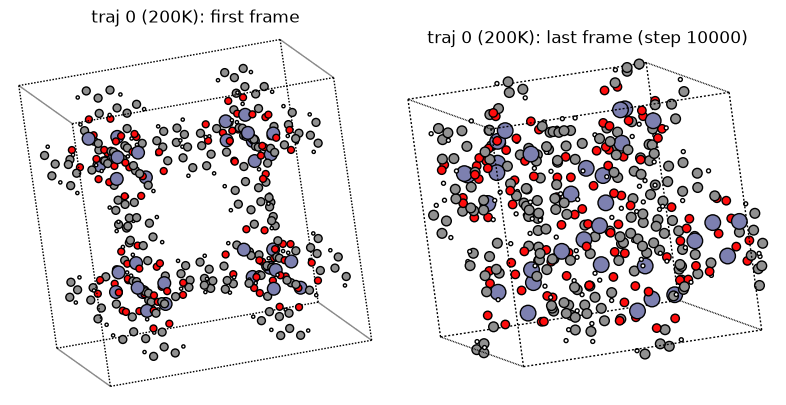

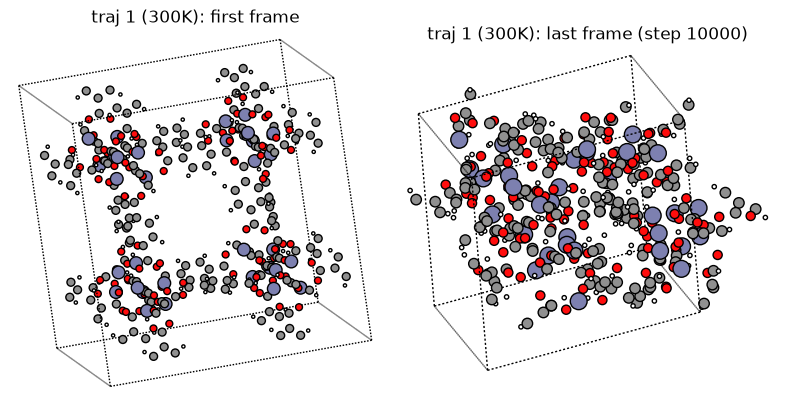

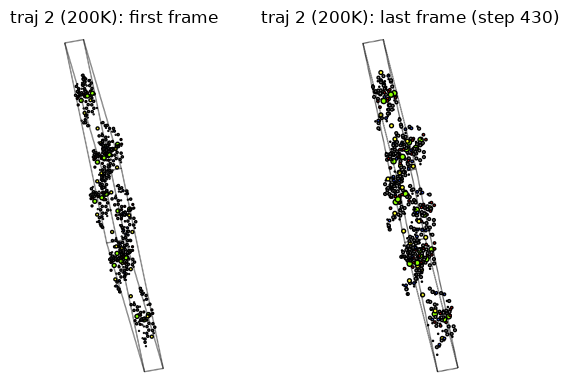

In [36]:
for traj_id in traj_ids:
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    if not traj:
        print(f'traj {traj_id}: no frames yet')
        continue

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    plot_atoms(traj[0], axes[0], radii=0.5, rotation='10x,10y,10z')
    plot_atoms(traj[-1], axes[1], radii=0.5, rotation='10x,10y,10z')
    axes[0].set_title(f'traj {traj_id} ({target_temps[traj_id]}K): first frame')
    axes[1].set_title(f'traj {traj_id} ({target_temps[traj_id]}K): last frame (step {len(traj) - 1})')

    for ax in axes:
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

## Temperature and pressure over time

Temperature comes from the momenta ASE stores on each frame; pressure is the isotropic part of the stored stress tensor (`-trace(stress) / 3`, converted to GPa).

In [37]:
rows = []
for traj_id in traj_ids:
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    for step, atoms in enumerate(traj):
        temperature_K = atoms.get_temperature()
        stress = atoms.calc.results.get('stress') if atoms.calc is not None else None
        # stress is stored in Voigt form [xx, yy, zz, yz, xz, xy]; pressure is the
        # isotropic part, i.e. the mean of the three normal (diagonal) components
        pressure_GPa = -np.mean(stress[:3]) / units.GPa if stress is not None else np.nan
        rows.append({
            'traj_id': traj_id,
            'step': step,
            'temperature_K': temperature_K,
            'pressure_GPa': pressure_GPa,
        })
npt_df = pd.DataFrame(rows)
npt_df.head()

,traj_id,step,temperature_K,pressure_GPa
0,0,0,205.205456,0.534673
1,0,1,210.928848,0.530234
2,0,2,219.394825,0.489782
3,0,3,221.554566,0.430321
4,0,4,218.663936,0.362622


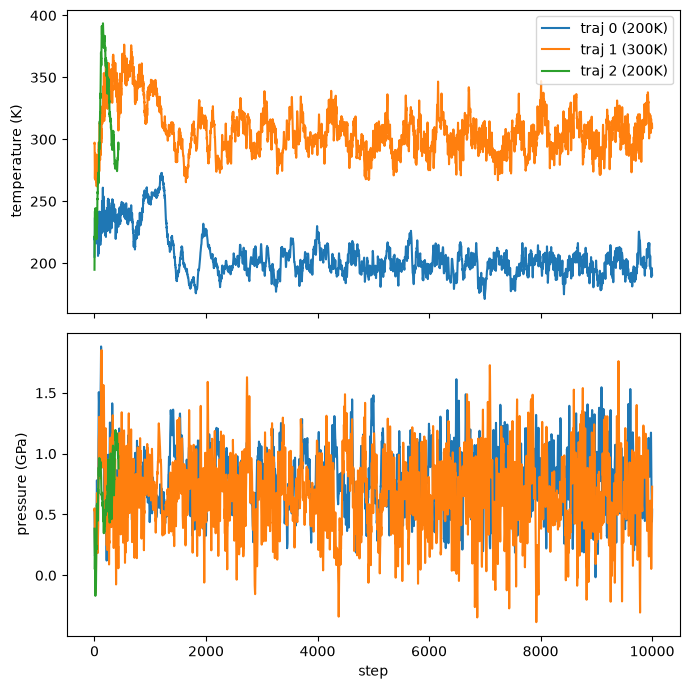

In [42]:
fig, (ax_temp, ax_press) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
for traj_id in traj_ids:
    sub = npt_df[npt_df['traj_id'] == traj_id]
    label = f'traj {traj_id} ({target_temps[traj_id]}K)'
    ax_temp.plot(sub['step'], sub['temperature_K'], label=label)
    ax_press.plot(sub['step'], sub['pressure_GPa'], label=label)

ax_temp.set_ylabel('temperature (K)')
ax_press.set_ylabel('pressure (GPa)')
ax_press.set_xlabel('step')
ax_temp.legend()
plt.tight_layout()
plt.show()